## $^{22}Na$ preprod @ 4.2 bar

* Check the efficiencie for the $^{22}Na$
* Check the energy spectra

In [1]:
import pandas as pd
import tables as tb
import glob
import numpy as np
from invisible_cities.io.dst_io import load_dst

import matplotlib.pyplot as plt

In [2]:
path = '/mnt/lustre/scratch/nlsas/home/usc/ie/mpm/NEXT100/data/HE_calib/final_LPR/{isotope}/'
file_path = path + 'prod/{port}/nexus/*.h5'

In [3]:
# NUMBER OF SIMULATED EVENTS
nevent_per_file = 10000
nfiles_per_port = 10
nevents_per_port = nevent_per_file * nfiles_per_port
nport = 4
nevents = nevents_per_port * nport

In [4]:
def get_mc_info(f):
    hit_df = load_dst(f, 'MC', 'hits')
    conf_df = load_dst(f, 'MC', 'configuration')
    hit_df = hit_df.merge(hit_df.groupby('event_id').energy.sum().rename('tot_ene'), on='event_id')
    hit_df = hit_df.merge(hit_df.groupby('event_id').size().rename('nhits'), on='event_id')
    hit_df_ = hit_df[['event_id', 'tot_ene', 'nhits']].drop_duplicates()

    hit_df_['port'] = conf_df[conf_df.param_key == '/Generator/IonGenerator/region'].param_value.values[0].replace(' ', '')
    return hit_df_

## $^{22}Na$

In [7]:
isotope = '22Na'

save_path_22Na = path.format(isotope=isotope) + '/summary_{isotope}.h4'.format(isotope=isotope)


In [6]:
# sim_evs_22Na = pd.DataFrame([{'sim_evs_per_file': nevent_per_file, 'sim_files_per_port': nfiles_per_port, 'n_ports':nport}])

# info_df_22Na = pd.DataFrame()
# for f in sorted(glob.glob(file_path.format(isotope=isotope, port='*')), key = lambda x: (x.split('/')[-3], int(x.split('_')[-2]))):
#     info_df_22Na = info_df_22Na.append(get_mc_info(f))

# info_df_22Na.to_hdf(save_path_22Na, key = 'events_info') 
# sim_evs_22Na.to_hdf(save_path_22Na, key = 'sim_info') 

In [8]:
info_df_22Na = pd.read_hdf(save_path_22Na, 'events_info')
sim_evs_22Na = pd.read_hdf(save_path_22Na, 'sim_info')

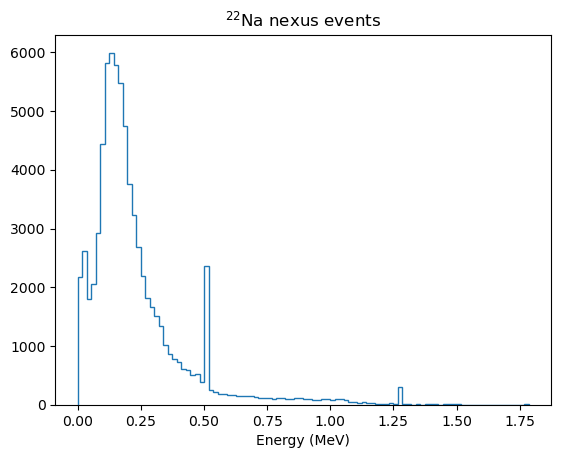

In [66]:
plt.hist(info_df_22Na.tot_ene, 100, histtype='step')
plt.xlabel('Energy (MeV)')
plt.title('$^{22}$Na nexus events')
# plt.xlim((0, 0.2))
# plt.yscale('log')
plt.show()

We can clearly see:

* Photopeak    @ 1.274 MeV
* Photopeak    @ 0.511 MeV

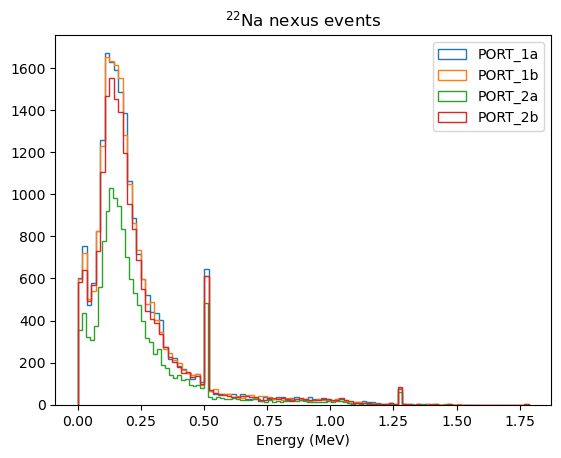

In [52]:
for port in info_df_22Na.port.unique():
    plt.hist(info_df_22Na[info_df_22Na.port == port].tot_ene, 100, histtype = 'step', label = port)
plt.xlabel('Energy (MeV)')
plt.title('$^{22}$Na nexus events')
plt.legend()
plt.show()

In [67]:
size_path = path.format(isotope=isotope) + '/size_data_compr.txt'
size_order = 'M'
with open(size_path, 'r') as f:
        text = f.readlines()
        f.close()
folder_size = [[isotope, t.split("\t")[1].split('/')[0].rstrip('\n'),float(t.split("\t")[0].rstrip(size_order).replace(',', '.'))] for t in text[:-1]]
size_df = pd.DataFrame(folder_size, columns = ['isotope', 'port', 'size'])

In [68]:
size_df

,isotope,port,size
0,22Na,PORT_1a,96.0
1,22Na,PORT_1b,96.0
2,22Na,PORT_2a,67.0
3,22Na,PORT_2b,89.0


In [69]:
def print_effs_and_sim(df, isotope, size_df, e_threshold = (0, np.inf), nevents_per_port = 5e4, nevents = 2e5, desired_events = 1e6, round_factor = 1e5, target_evs_file = 2e4):
    df = df[(df.tot_ene > e_threshold[0]) & (df.tot_ene < e_threshold[1])]
    size_df = size_df[size_df.isotope == isotope].drop(columns='isotope').set_index('port')['size']
    port_eff = df.groupby('port').size() / nevents_per_port

    print('MC efficiencies ({} < E < {})'.format(e_threshold[0], e_threshold[1]))
    print('Each port:')
    print(port_eff)
    print('')

    print('Total efficiency')
    print(len(df) / nevents)

    print('')
    print('In each port we will need to simulate (to have at least {} events):'.format(desired_events))
    print(desired_events / port_eff)

    print('')
    print('Which we can set up to:')
    target_evs_port = np.ceil((desired_events / port_eff).max() / round_factor) * round_factor
    print(target_evs_port, ' events per port')
    print(target_evs_port / target_evs_file, ' tasks/files per port if we simulate ', target_evs_file, ' events per file')
    print('With the current eff, these files will have around ', target_evs_file * port_eff.mean(), ' events per file')
    print('')
    print('For having {}, we expect that the production will occupy:'.format(desired_events))
    expected_size = size_df / df.groupby('port').size() * desired_events
    print(expected_size)
    print('In total: {} M'.format(expected_size.sum()))
    return port_eff, expected_size

In [70]:
port_eff, expected_size = print_effs_and_sim(info_df_22Na, 
                                            isotope, 
                                            size_df, 
                                            e_threshold = (0, np.inf), 
                                            nevents_per_port = nevents_per_port, 
                                            nevents = nevents, 
                                            desired_events = 1e6, 
                                            round_factor = 1e5, 
                                            target_evs_file = 3e4)


MC efficiencies (0 < E < inf)
Each port:
port
PORT_1a    0.20797
PORT_1b    0.20577
PORT_2a    0.14379
PORT_2b    0.19162
dtype: float64

Total efficiency
0.1872875

In each port we will need to simulate (to have at least 1000000.0 events):
port
PORT_1a    4.808386e+06
PORT_1b    4.859795e+06
PORT_2a    6.954587e+06
PORT_2b    5.218662e+06
dtype: float64

Which we can set up to:
7000000.0  events per port
233.33333333333334  tasks/files per port if we simulate  30000.0  events per file
With the current eff, these files will have around  5618.625  events per file

For having 1000000.0, we expect that the production will occupy:
port
PORT_1a    4616.050392
PORT_1b    4665.403120
PORT_2a    4659.572988
PORT_2b    4644.609122
dtype: float64
In total: 18585.635622478683 M


In [81]:
port_eff, expected_size = print_effs_and_sim(info_df_22Na, 
                                            isotope, 
                                            size_df, 
                                            e_threshold = (0.50, 0.52), 
                                            nevents_per_port = nevents_per_port, 
                                            nevents = nevents, 
                                            desired_events = 1e6, 
                                            round_factor = 1e5, 
                                            target_evs_file = 3e4)

MC efficiencies (0.5 < E < 0.52)
Each port:
port
PORT_1a    0.00654
PORT_1b    0.00623
PORT_2a    0.00497
PORT_2b    0.00619
dtype: float64

Total efficiency
0.0059825

In each port we will need to simulate (to have at least 1000000.0 events):
port
PORT_1a    1.529052e+08
PORT_1b    1.605136e+08
PORT_2a    2.012072e+08
PORT_2b    1.615509e+08
dtype: float64

Which we can set up to:
201300000.0  events per port
6710.0  tasks/files per port if we simulate  30000.0  events per file
With the current eff, these files will have around  179.475  events per file

For having 1000000.0, we expect that the production will occupy:
port
PORT_1a    146788.990826
PORT_1b    154093.097913
PORT_2a    134808.853119
PORT_2b    143780.290792
dtype: float64
In total: 579471.2326493224 M


#### Plot an scheme of the detector with the efficiencies

In [78]:
# Cylinder surface parameters
radius = 67.555
zmin = -84
zmax = +84
resolution = 200  # Number of points to approximate the cylinder's surface

def cylinder_surface(rad, zmin, zmax, resol):
    # Create points for the cylinder's surface
    theta = np.linspace(0, 2 * np.pi, resol)
    z = np.linspace(zmin, zmax, resol)
    Theta, Z = np.meshgrid(theta, z)
    X = rad * np.cos(Theta)
    Y = rad * np.sin(Theta)
    return X, Y, Z

# Ports of the cylinder
port_x = ( 47.77, -47.77, 47.477, -47.77)
port_y = ( 47.77, 47.477,  47.77,  47.77)
port_z = (-13.95, -30.79,  45.05,  19.21)
port_n = ('PORT_1a', 'PORT_1b', 'PORT_2a', 'PORT_2b')
port_info = [port_x, port_y, port_z, port_n]

# Eff for each port in a energy range
e_range = (0.50, 0.52)
desired_events = 1e5

port_eff_137Cs, exp_size_137Cs = print_effs_and_sim(info_df_22Na, 
                                                    isotope, 
                                                    size_df, 
                                                    e_threshold = e_range, 
                                                    nevents_per_port = nevents_per_port, 
                                                    nevents = nevents, 
                                                    desired_events = desired_events, 
                                                    round_factor = 1e5, 
                                                    target_evs_file = 3e4)

MC efficiencies (0.5 < E < 0.52)
Each port:
port
PORT_1a    0.00654
PORT_1b    0.00623
PORT_2a    0.00497
PORT_2b    0.00619
dtype: float64

Total efficiency
0.0059825

In each port we will need to simulate (to have at least 100000.0 events):
port
PORT_1a    1.529052e+07
PORT_1b    1.605136e+07
PORT_2a    2.012072e+07
PORT_2b    1.615509e+07
dtype: float64

Which we can set up to:
20200000.0  events per port
673.3333333333334  tasks/files per port if we simulate  30000.0  events per file
With the current eff, these files will have around  179.475  events per file

For having 100000.0, we expect that the production will occupy:
port
PORT_1a    14678.899083
PORT_1b    15409.309791
PORT_2a    13480.885312
PORT_2b    14378.029079
dtype: float64
In total: 57947.123264932234 M


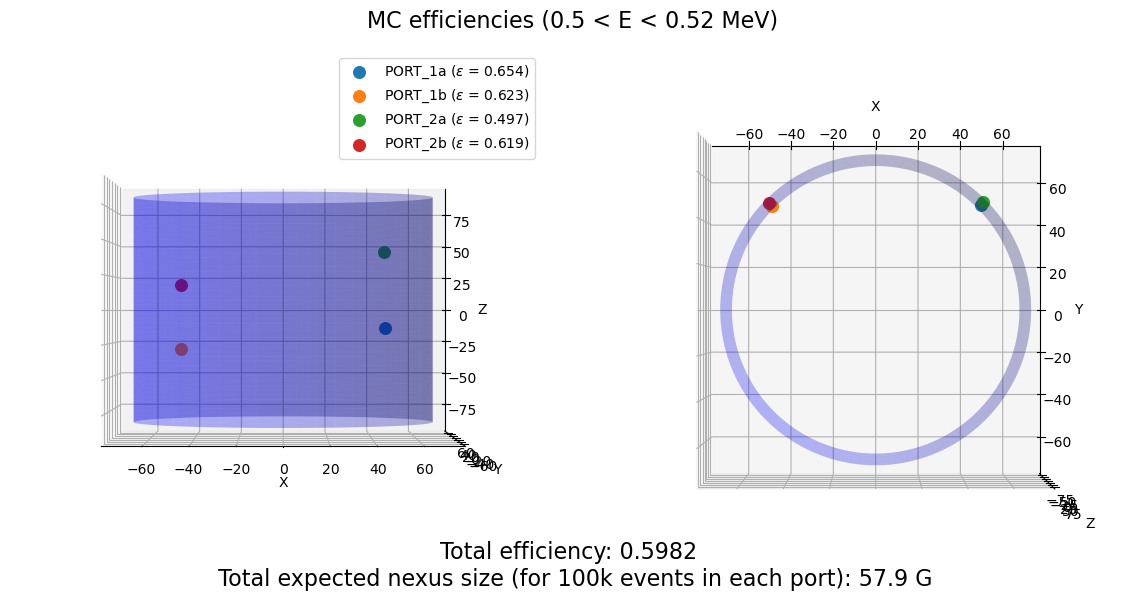

In [79]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize = (12, 6))

cyl_surf = cylinder_surface(radius, zmin, zmax, resolution)

def plot_next100_scheme(fig, subplot, cyl_surf, port_info, port_eff, ang = (0, 0)):
    # Create a 3D figure
    
    ax = fig.add_subplot(subplot, projection='3d')

    # Plot the surface of the cylinder
    X, Y, Z = cyl_surf[0], cyl_surf[1], cyl_surf[2]
    ax.plot_surface(X, Y, Z, color='b', alpha= 0.3)

    # Plot the ports of the cylinder
    port_x, port_y, port_z, port_n = port_info
    for x, y, z, n in zip(port_x, port_y, port_z, port_n):
        ax.scatter(x, y, z, marker='o', s=70, label=n + ' ($\epsilon$ = {:.4})'.format(port_eff[n] * 100))
    
    # Set axis labels
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.view_init(elev=ang[0], azim=ang[1]) 
    return ax

plt.suptitle('MC efficiencies ({} < E < {} MeV)'.format(e_range[0], e_range[1]), fontsize=16)
fig.text(0.5, 0.02, 'Total efficiency: {:.4} \n Total expected nexus size (for {}k events in each port): {:.3} G'.format(port_eff_137Cs.mean() * 100, int(desired_events / 1000), exp_size_137Cs.sum() / 1000), ha='center', fontsize=16)
ax = plot_next100_scheme(fig, 121, cyl_surf, port_info, port_eff_137Cs, ang=(0, -90))
ax.legend()
ax = plot_next100_scheme(fig, 122, cyl_surf, port_info, port_eff_137Cs, ang=(90, 270))
plt.tight_layout()

# Show the plot
plt.show()

In [77]:
exp_size_22Na

NameError: name 'exp_size_22Na' is not defined